# **Problem Statement**

## **Business Context**

Workplace safety in hazardous environments like construction sites and industrial plants is crucial to prevent accidents and injuries. One of the most important safety measures is ensuring workers wear safety helmets, which protect against head injuries from falling objects and machinery. Non-compliance with helmet regulations increases the risk of serious injuries or fatalities, making effective monitoring essential, especially in large-scale operations where manual oversight is prone to errors and inefficiency.

To overcome these challenges, SafeGuard Corp plans to develop an automated image analysis system capable of detecting whether workers are wearing safety helmets. This system will improve safety enforcement, ensuring compliance and reducing the risk of head injuries. By automating helmet monitoring, SafeGuard aims to enhance efficiency, scalability, and accuracy, ultimately fostering a safer work environment while minimizing human error in safety oversight.

## **Objective**

As a data scientist at SafeGuard Corp, you are tasked with developing an image classification model that classifies images into one of two categories:
- **With Helmet:** Workers wearing safety helmets.
- **Without Helmet:** Workers not wearing safety helmets.

## **Data Description**

The dataset consists of **4125 images**, divided into two categories:

- **With Helmet:** 3161 images showing workers wearing helmets.
- **Without Helmet:** 964 images showing workers not wearing helmets.

**Dataset Characteristics:**
- **Variations in Conditions:** Images include diverse environments such as construction sites, factories, and industrial settings, with variations in lighting, angles, and worker postures to simulate real-world conditions.
- **Worker Activities:** Workers are depicted in different actions such as standing, using tools, or moving, ensuring robust model learning for various scenarios.

# **Installing and Importing the Necessary Libraries**

In [1]:
!pip install tensorflow[and-cuda] scikit-learn==1.6.1 opencv-python==4.12.0.88 seaborn==0.13.2 matplotlib==3.10.0 numpy==2.0.2 pandas==2.2.2 -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.0/67.0 MB 11.8 MB/s eta 0:00:00


**Note:**

- After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab) and run all cells sequentially from the next cell.

- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [2]:
import os
import random
import numpy as np                                                                               # Importing numpy for Matrix Operations
import pandas as pd
import seaborn as sns
import matplotlib.image as mpimg                                                                              # Importing pandas to read CSV files
import matplotlib.pyplot as plt                                                                  # Importting matplotlib for Plotting and visualizing images
import math                                                                                      # Importing math module to perform mathematical operations
import cv2


# Tensorflow modules
import keras
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator                              # Importing the ImageDataGenerator for data augmentation
from tensorflow.keras.models import Sequential                                                   # Importing the sequential module to define a sequential model
from tensorflow.keras.layers import Dense,Dropout,Flatten,Conv2D,MaxPooling2D,BatchNormalization # Defining all the layers to build our CNN Model
from tensorflow.keras.optimizers import Adam,SGD                                                 # Importing the optimizers which can be used in our model
from sklearn import preprocessing                                                                # Importing the preprocessing module to preprocess the data
from sklearn.model_selection import train_test_split                                             # Importing train_test_split function to split the data into train and test
from sklearn.metrics import confusion_matrix
from tensorflow.keras.models import Model
from keras.applications.vgg16 import VGG16                                               # Importing confusion_matrix to plot the confusion matrix

# Display images using OpenCV
from google.colab.patches import cv2_imshow

#Imports functions for evaluating the performance of machine learning models
from sklearn.metrics import confusion_matrix, f1_score,accuracy_score, recall_score, precision_score, classification_report
from sklearn.metrics import mean_squared_error as mse                                                 # Importing cv2_imshow from google.patches to display images

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [3]:
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))
print(tf.__version__)

Num GPUs Available: 1
2.20.0


In [4]:
# 1. Set Python random seed
random.seed(812)

# 2. Set NumPy random seed
np.random.seed(812)

# 3. Set TensorFlow seed (covers Keras + backend)
tf.keras.utils.set_random_seed(812)

# 4. Enable deterministic GPU ops (if using GPU)
tf.config.experimental.enable_op_determinism()

# **Data Overview**


##Loading the data

In [31]:
images = np.load('images.npy')

labels = pd.read_csv('labels.csv')

# **Exploratory Data Analysis**

###Plot random images from each of the classes and print their corresponding labels.

In [32]:
def helmet_check(label_val):
    val = label_val.iloc[0] if hasattr(label_val, 'iloc') else label_val
    if val == 1:
        return "Helmet"
    else:
        return "No Helmet"

In [40]:
def plot_images(images,labels):
  num_classes=10                                                                  # Number of Classes
  categories=np.unique(labels)
  keys=dict(labels['label'])                                                      # Obtaing the unique classes from y_train
  rows = 3                                                                        # Defining number of rows=3
  cols = 4                                                                        # Defining number of columns=4
  fig = plt.figure(figsize=(10, 8))                                               # Defining the figure size to 10x8
  for i in range(cols):
      for j in range(rows):
          random_index = np.random.randint(0, len(labels))                        # Generating random indices from the data and plotting the images
          ax = fig.add_subplot(rows, cols, i * rows + j + 1)                      # Adding subplots with 3 rows and 4 columns
          ax.imshow(images[random_index, :])                                      # Plotting the image
          ax.set_title(keys[random_index])
  plt.show()

In [34]:
print(labels.head(10))
print(labels.columns)

   label
0      0
1      0
2      0
3      0
4      0
5      0
6      0
7      0
8      0
9      0
Index(['label'], dtype='object')


In [45]:
print(images.shape)
print(labels.shape)
print(images[0].shape)

(4125, 200, 200, 3)
(4125, 1)
(200, 200, 3)


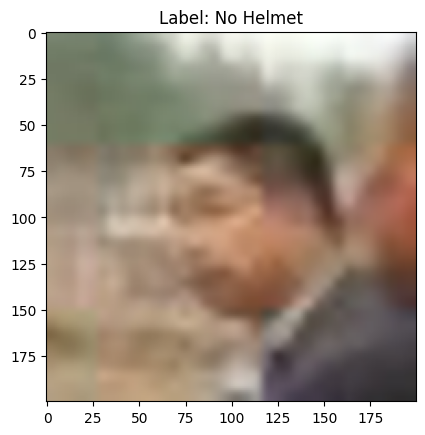

In [36]:
plt.imshow(images[0])
plt.title(f"Label: {helmet_check(labels.iloc[0].item())}")
plt.show()

In [37]:
# Converting the images from BGR to RGB using cvtColor function of OpenCV
for i in range(len(images)):
  images[i] = cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB)

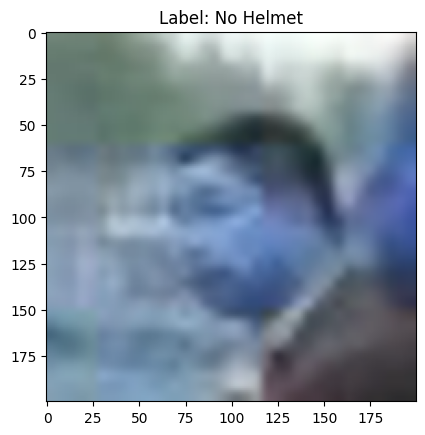

In [38]:
plt.imshow(images[0])
plt.title(f"Label: {helmet_check(labels.iloc[0].item())}")
plt.show()

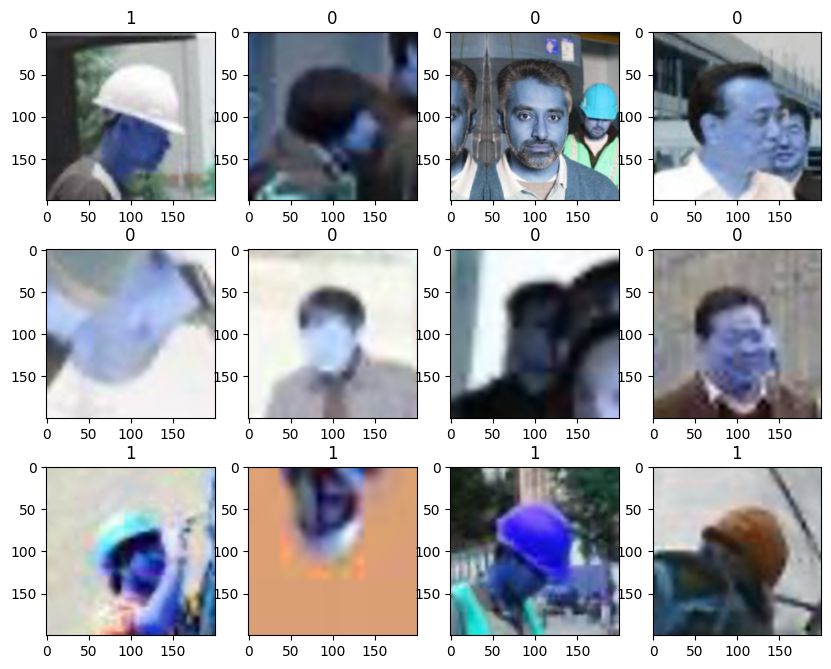

In [41]:
plot_images(images,labels)

## Checking for class imbalance


Helmet:     3161 (76.6%)
No Helmet:  964 (23.4%)


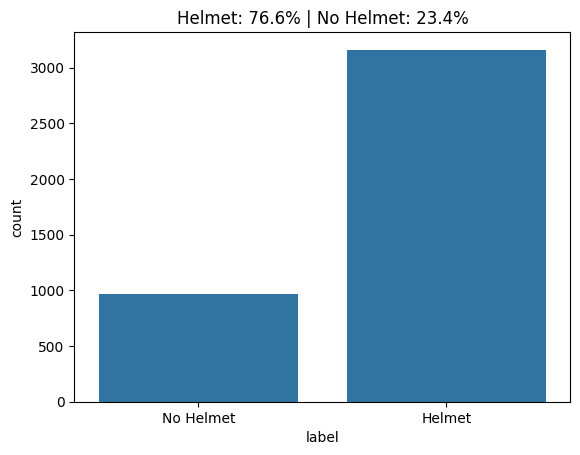

In [56]:
counts = labels['label'].value_counts()
percentages = labels['label'].value_counts(normalize=True) * 100

print(f"Helmet:     {counts[1]} ({percentages[1]:.1f}%)")
print(f"No Helmet:  {counts[0]} ({percentages[0]:.1f}%)")

sns.countplot(x=labels['label'])
plt.xticks([0, 1], ['No Helmet', 'Helmet'])
plt.title(f"Helmet: {percentages[1]:.1f}% | No Helmet: {percentages[0]:.1f}%")
plt.show()

only around a quarter of the images show someone with no helmet so there is a decent imbalance between the two.


# **Data Preprocessing**

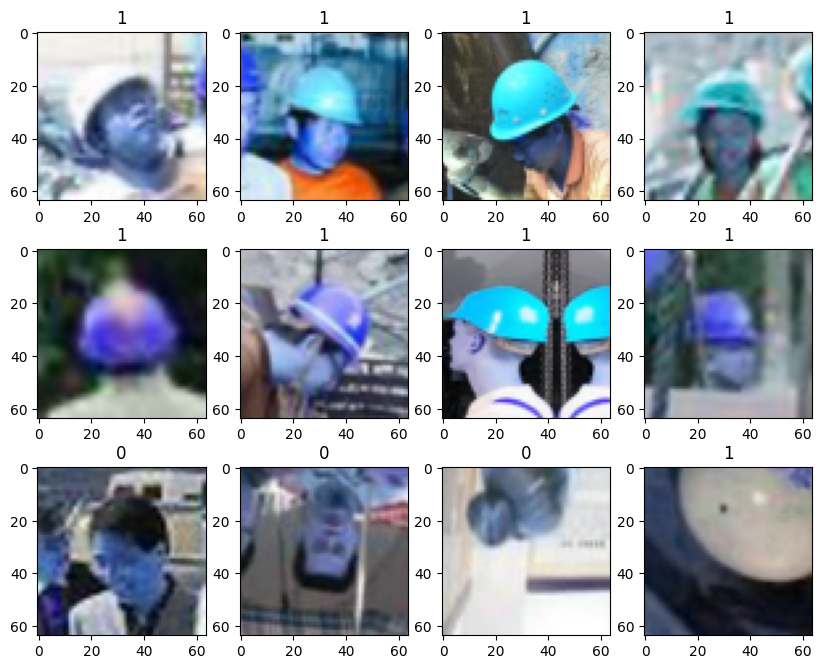

In [51]:
dimensions = (64, 64)
images_decreased = [cv2.resize(img, dimensions, interpolation=cv2.INTER_AREA) for img in images]
images_decreased = np.array(images_decreased)
plot_images(images_decreased, labels)

In [48]:
print(images_decreased[0].shape)
print(len(images_decreased))

(64, 64, 3)
4125


In [53]:
# Applying Gaussian Blur to denoise the images
images_gb=[]
for i in range(len(images_decreased)):
    images_gb.append(cv2.GaussianBlur(images_decreased[i], ksize =(3,3),sigmaX =  0))
images_gb_np = np.array(images_gb)

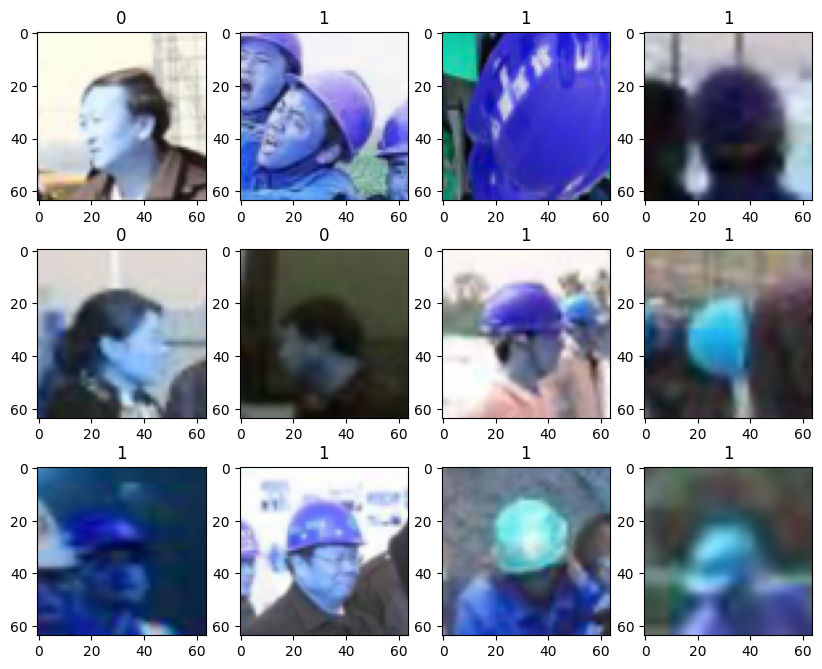

In [54]:
plot_images(images_decreased, labels)

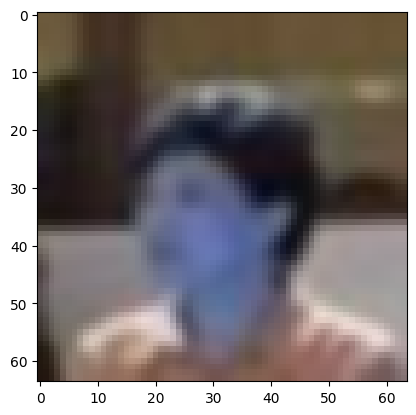

In [55]:
plt.imshow(images_gb[3]);


### Splitting the dataset



### Data Normalization

# **Model Building**

##Model Evaluation Criterion

## Utility Functions

In [ ]:
# defining a function to compute different metrics to check performance of a classification model built using statsmodels
def model_performance_classification(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # checking which probabilities are greater than threshold
    pred = model.predict(predictors).reshape(-1)>0.5

    target = target.to_numpy().reshape(-1)


    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred, average='micro')  # to compute Recall
    precision = precision_score(target, pred, average='micro')  # to compute Precision
    f1 = f1_score(target, pred, average='micro')  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame({"Accuracy": acc, "Recall": recall, "Precision": precision, "F1 Score": f1,},index=[0],)

    return df_perf

In [ ]:
def plot_confusion_matrix(model,predictors,target,ml=False):
    """
    Function to plot the confusion matrix

    model: classifier
    predictors: independent variables
    target: dependent variable
    ml: To specify if the model used is an sklearn ML model or not (True means ML model)
    """

    # checking which probabilities are greater than threshold
    pred = model.predict(predictors).reshape(-1)>0.5

    target = target.to_numpy().reshape(-1)

    # Plotting the Confusion Matrix using confusion matrix() function which is also predefined tensorflow module
    confusion_matrix = tf.math.confusion_matrix(target,pred)
    f, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(
        confusion_matrix,
        annot=True,
        linewidths=.4,
        fmt="d",
        square=True,
        ax=ax
    )
    plt.show()

##Model 1: Convolutional Neural Network (CNN) from Scratch

### Visualizing the predictions

## Model 2: Transfer Learning with VGG-16 (Base)

### Visualizing the predictions

## Model 3: Transfer Learning with VGG-16 (Base + FFNN)





#### Visualizing the predictions

## Model 4: Transfer Learning with VGG-16 (Base + FFNN + Data Augmentation)

- In most of the real-world case studies, it is challenging to acquire a large number of images and then train CNNs.
- To overcome this problem, one approach we might consider is **Data Augmentation**.
- CNNs have the property of **translational invariance**, which means they can recognise an object even if its appearance shifts translationally in some way. - Taking this attribute into account, we can augment the images using the techniques listed below

    -  Horizontal Flip (should be set to True/False)
    -  Vertical Flip (should be set to True/False)
    -  Height Shift (should be between 0 and 1)
    -  Width Shift (should be between 0 and 1)
    -  Rotation (should be between 0 and 180)
    -  Shear (should be between 0 and 1)
    -  Zoom (should be between 0 and 1) etc.

Remember, **data augmentation should not be used in the validation/test data set**.

#### Visualizing the predictions

# **Model Performance Comparison and Final Model Selection**

## Test Performance

# **Actionable Insights & Recommendations**

-
-

<font size=5 color='blue'>Power Ahead!</font>
___